# SIT720 11.1HD: a simple reproduction study

**Paper option 3:** Bhagat, Sharma and Agarwal, *An efficient stacking-based
ensemble technique for early heart attack prediction*, DOI
[10.1007/s11042-024-19293-7](https://doi.org/10.1007/s11042-024-19293-7).

This notebook reproduces six basic models and stacking, then tests a simpler
pipeline. The same code creates the report's numerical results. It uses the
paper's linked dataset, not a substitute or synthetic dataset.

**How to use it:** select the project Python environment, then Restart Kernel and
Run All. Run from the `hd_submission` folder. No internet is needed after package
installation. The output cells are already populated from a complete run.


## 1. Load the data

`pandas` helps us work with tables. Each CSV row contains 13 predictors and one
target. The target is what we predict, so it must never be included as an input.
All metrics treat the original CSV's `target=1` as positive, following the paper.
This is a numerical convention, not independently verified clinical labelling.


In [1]:
from pathlib import Path
import inspect
import json
import pandas as pd
from IPython.display import display, Image
from run_experiments import (
    read_data, FEATURES, NUMERIC, CATEGORICAL, METRICS,
    make_models, make_proposed_model, choose_threshold, get_scores, main
)

ROOT = Path.cwd()
assert (ROOT / "data/heart.csv").exists(), "Open the notebook in hd_submission."
data = read_data()
print("Dataset shape:", data.shape)
print("Input features:", FEATURES)
display(data.head())

Dataset shape: (1025, 14)
Input features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [2]:
print("Missing cells:", data.isna().sum().sum())
print("Extra exact duplicate rows:", data.duplicated().sum())
print("Class counts before duplicate removal:")
display(data.target.value_counts().sort_index().rename("rows").to_frame())

clean = data.drop_duplicates(subset=FEATURES).copy()
print("Distinct records:", len(clean))
display(clean.target.value_counts().sort_index().rename("distinct records").to_frame())

Missing cells: 0
Extra exact duplicate rows: 723
Class counts before duplicate removal:


,rows
target,
0,499
1,526


Distinct records: 302


,distinct records
target,
0,138
1,164


There are **723 extra repeated rows** and only **302 distinct records**.
Copies of the same record can land in both training and test sets if we split
the original rows randomly. A model may then recognise records it has already
seen. Distinct rows do not necessarily mean distinct patients: there is no
patient identifier in this file.

The file has no NaNs, so the paper's missing-value imputation has nothing to
fill here. We keep the unusual `ca=4` and `thal=0` codes instead of guessing
their meaning. See `data/SOURCE.md` for provenance and limitations.


## 2. Understand the models and assumptions

| Model | Simple explanation |
| --- | --- |
| Logistic regression | Turns a weighted sum of inputs into a class probability. |
| Decision tree | Makes a sequence of if/else decisions. |
| Random forest | Combines many trees trained with random variation. |
| XGBoost | Adds trees in stages to improve predictions. |
| Naive Bayes | Uses probability calculations with a feature-independence assumption. |
| KNN | Predicts using nearby training records. |
| Stacking | Learns how to combine the six models' probabilities. |

The paper does not state its exact split seed, scaler, encoder, final classifier
or most hyperparameters. We use fixed, documented assumptions. An 80/20 split
is inferred from the paper's 205 test observations out of 1,025. We do not search
for settings that reproduce a desired number.

The following cell shows the actual function used to construct the models.
`make_pipeline` puts scaling and the classifier together. Each stacking fold
fits its own scaler using that fold's training rows. The complete source is in
`run_experiments.py`; no model implementation is hidden or downloaded.


In [3]:
print(inspect.getsource(make_models))

def make_models(seed):
    """All unspecified settings are ordinary, fixed choices, not tuned results."""
    classifiers = {
        "LR": LogisticRegression(C=1.0, solver="lbfgs", max_iter=2000),
        "DT": DecisionTreeClassifier(criterion="entropy", random_state=seed),
        "RF": RandomForestClassifier(n_estimators=100, criterion="gini",
                                     max_features="sqrt", random_state=seed, n_jobs=1),
        "XGB": XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.3,
                             subsample=1.0, colsample_bytree=1.0,
                             reg_lambda=1.0, objective="binary:logistic",
                             eval_metric="logloss", tree_method="hist",
                             random_state=seed, n_jobs=1),
        "NB": GaussianNB(var_smoothing=1e-9),
        "KNN": KNeighborsClassifier(n_neighbors=5, weights="uniform", p=2),
    }
    # Each learner gets its own scaler. Stacking clones these whole pipelines.
    mo

The stack uses five-fold **out-of-fold predictions**. Each training record
gets a probability from a base learner that was fitted on the other folds.
These probabilities teach the final LR classifier. The outer test set is kept
outside this process. However, copies of a record still cause a problem in the
raw dataset, so Part 2 removes them before any split.

## 3. Run the complete experiment

This cell runs the whole study: the raw 80/20 split, then ten duplicate-free
splits with seeds 42 through 51. All original models and the proposed methods
use the same clean split for each seed. It saves metrics, predictions, split IDs,
audits and plots. The design is described in `report/study_plan.md`.


In [4]:
scores = main()

Running paper_rows, seed 42


Running unique_rows, seed 42


Running unique_rows, seed 43


Running unique_rows, seed 44


Running unique_rows, seed 45


...

Running unique_rows, seed 48


Running unique_rows, seed 49


Running unique_rows, seed 50


Running unique_rows, seed 51



Part 1 (scores from actual execution):
   model  accuracy  precision  recall     f1    auc
      LR    0.7951     0.7563  0.8738 0.8108 0.8787
      DT    0.9854     1.0000  0.9709 0.9852 0.9854
      RF    0.9854     1.0000  0.9709 0.9852 1.0000
     XGB    0.9854     1.0000  0.9709 0.9852 0.9894
      NB    0.8000     0.7541  0.8932 0.8178 0.8706
     KNN    0.8341     0.8000  0.8932 0.8440 0.9486
Stacking    0.9854     1.0000  0.9709 0.9852 1.0000

Part 2 mean scores over ten duplicate-free splits:
           accuracy_mean  precision_mean  recall_mean  f1_mean  auc_mean
model                                                                   
DT                0.7557          0.7938       0.7424   0.7644    0.7569
KNN               0.8082          0.8075       0.8545   0.8291    0.8662
LR                0.8311          0.8270       0.8758   0.8490    0.8997
NB                0.8148          0.8284       0.8364   0.8303    0.8890
OneHot LR         0.8590          0.8583       0.8879 

## 4. Compare the reproduction with the paper

The published numbers below are a clearly labelled transcription of Table 11.
They are not generated results. The `This study` rows come from the experiment.


,model,source,accuracy,precision,recall,f1,auc
1,DT,Paper Table 11,0.9268,0.9702,0.8909,0.9289,0.9702
1,DT,This study,0.9854,1.0000,0.9709,0.9852,0.9854
5,KNN,Paper Table 11,0.8585,0.8648,0.8727,0.8687,0.9304
5,KNN,This study,0.8341,0.8000,0.8932,0.8440,0.9486
0,LR,Paper Table 11,0.8439,0.8196,0.9090,0.8620,0.9204
0,LR,This study,0.7951,0.7563,0.8738,0.8108,0.8787
4,NB,Paper Table 11,0.8439,0.8250,0.9000,0.8608,0.9185
4,NB,This study,0.8000,0.7541,0.8932,0.8178,0.8706
2,RF,Paper Table 11,0.9268,0.9130,0.9545,0.9333,0.9734
2,RF,This study,0.9854,1.0000,0.9709,0.9852,1.0000


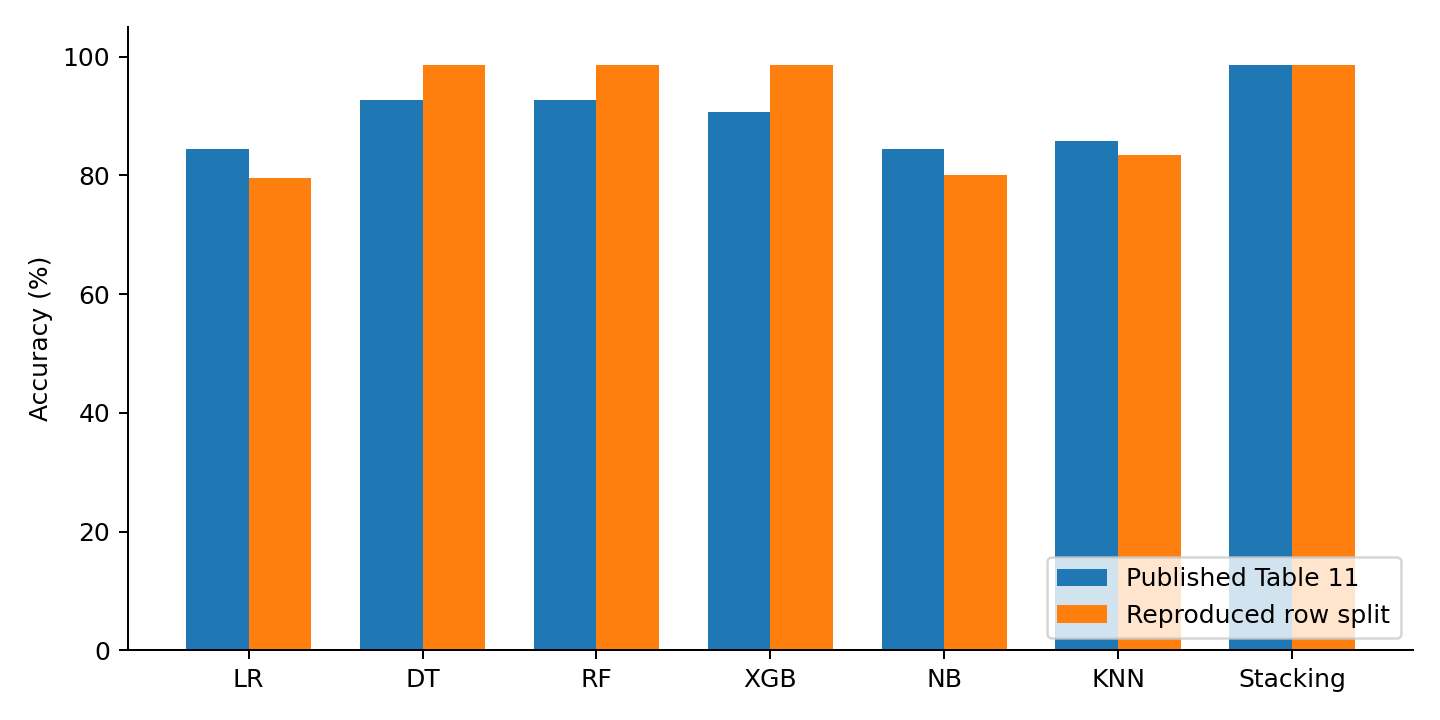

In [5]:
published = pd.read_csv("results/published_table11.csv")
reproduced = scores[scores.protocol == "paper_rows"][["model"] + METRICS]
comparison = pd.concat([
    published.assign(source="Paper Table 11"),
    reproduced.assign(source="This study")
]).sort_values(["model", "source"])
display(comparison[["model", "source"] + METRICS].round(4))
display(Image(filename="results/figures/paper_comparison.png", width=800))

In [6]:
split_audit = pd.read_csv("results/split_audit.csv")
display(split_audit)
raw_audit = split_audit.iloc[0]
print(f"Raw test rows with training copies: {raw_audit.test_rows_seen_in_training}"
      f" / {raw_audit.test_rows}")

,protocol,seed,train_rows,test_rows,test_rows_seen_in_training,test_positive,test_negative
0,paper_rows,42,820,205,199,103,102
1,unique_rows,42,241,61,0,33,28
2,unique_rows,43,241,61,0,33,28
3,unique_rows,44,241,61,0,33,28
4,unique_rows,45,241,61,0,33,28
5,unique_rows,46,241,61,0,33,28
6,unique_rows,47,241,61,0,33,28
7,unique_rows,48,241,61,0,33,28
8,unique_rows,49,241,61,0,33,28
9,unique_rows,50,241,61,0,33,28


Raw test rows with training copies: 199 / 205


The raw stack gets **98.54% accuracy**, close to the published **98.53%**.
But **199 of 205 test rows** have a training copy. A similar percentage therefore
does not establish good performance on unseen records, or exact replication of
the paper. Our test class counts also differ from the paper's figures.

The paper gives inconsistent values for sensitivity, specificity and MCC.
The report checks them against its confusion matrix. Our metrics are calculated
from predictions instead of copying those inconsistent columns.


## 5. A simpler proposed solution

1. Remove duplicate records before splitting.
2. Scale the five continuous measurements using training statistics.
3. One-hot encode the eight discrete predictors, so category codes do not imply
   an arbitrary numeric order or distance.
4. Fit one regularised logistic regression model.
5. Select a threshold using only five-fold training predictions. Maximise F2,
   which gives recall more weight than precision. The choices are 0.20 to 0.80
   in steps of 0.05, fixed in advance.

This redesign covers data integrity, feature representation and the prediction
rule. It is a small application of established techniques, not a claim to have
invented a new learning algorithm. Lower thresholds can find more positive
records but also create more false positives. This is not a clinically validated
threshold-selection objective.


In [7]:
print(inspect.getsource(make_proposed_model))
print(inspect.getsource(choose_threshold))

def make_proposed_model():
    """One understandable model with separate numeric and category handling."""
    preprocessing = ColumnTransformer([
        ("numeric", StandardScaler(), NUMERIC),
        ("category", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         CATEGORICAL),
    ])
    return make_pipeline(preprocessing, LogisticRegression(C=1.0, max_iter=2000))

def choose_threshold(model, X_train, y_train, seed):
    """Only training-fold predictions choose the threshold, never test labels."""
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    # Each row is predicted by a model trained on the other four folds.
    probabilities = cross_val_predict(model, X_train, y_train, cv=folds,
                                      method="predict_proba", n_jobs=1)[:, 1]
    rows = []
    for threshold in np.round(np.arange(0.20, 0.801, 0.05), 2):
        prediction = (probabilities >= threshold).astype(int)
        rows.append({"threshold": float

## 6. Live demonstration for the video

This small cell fits only the proposed model at seed 42. Show the split sizes,
threshold and output metrics during the recording. The test labels are only
passed to evaluation after threshold selection is finished.


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    clean[FEATURES], clean.target, test_size=0.20,
    stratify=clean.target, random_state=42
)
model = make_proposed_model()
threshold, threshold_results = choose_threshold(model, X_train, y_train, seed=42)
model.fit(X_train, y_train)
probabilities = model.predict_proba(X_test)[:, 1]
demo_metrics = get_scores(y_test, probabilities, threshold)

print("Training records:", len(X_train), "Test records:", len(X_test))
print("Chosen threshold (training data only):", threshold)
display(pd.DataFrame([demo_metrics]).round(4))
display(threshold_results.drop(columns="distance_from_half").round(4))

Training records: 241 Test records: 61
Chosen threshold (training data only): 0.4


,accuracy,precision,recall,f1,auc,specificity,mcc,f2,tn,fp,fn,tp
0,0.8197,0.8235,0.8485,0.8358,0.9048,0.7857,0.6363,0.8434,22,6,5,28


,threshold,f2,precision,recall
0,0.20,0.9091,0.7456,0.9618
1,0.25,0.9012,0.7561,0.9466
2,0.30,0.9118,0.7949,0.9466
3,0.35,0.9111,0.8146,0.9389
4,0.40,0.9118,0.8414,0.9313
5,0.45,0.8886,0.8429,0.9008
6,0.50,0.8712,0.8456,0.8779
7,0.55,0.8537,0.8485,0.8550
8,0.60,0.8243,0.8560,0.8168
9,0.65,0.8009,0.8655,0.7863


## 7. Fair comparison on duplicate-free data

The meaningful comparison is between models evaluated on identical clean test
sets. The published raw-split score is a historical reference, not a comparable
test of our new pipeline. Means and standard deviations below describe ten
splits of the same small dataset; they are not independent cohort estimates.

**Ablation** means testing parts of the proposed change separately. Here we
compare ordinary LR, one-hot LR at 0.5, and one-hot LR with a tuned threshold.


,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,auc_mean,auc_std
model,,,,,,,,,,
DT,0.7557,0.0521,0.7938,0.0457,0.7424,0.0961,0.7644,0.0595,0.7569,0.0495
KNN,0.8082,0.0501,0.8075,0.0619,0.8545,0.0373,0.8291,0.0398,0.8662,0.0516
LR,0.8311,0.0579,0.8270,0.0647,0.8758,0.0630,0.8490,0.0508,0.8997,0.0411
NB,0.8148,0.0669,0.8284,0.0776,0.8364,0.0731,0.8303,0.0613,0.8890,0.0543
OneHot LR,0.8590,0.0624,0.8583,0.0625,0.8879,0.0554,0.8724,0.0550,0.9221,0.0368
Proposed,0.8197,0.0557,0.7834,0.0488,0.9242,0.0593,0.8472,0.0466,0.9221,0.0368
RF,0.8230,0.0500,0.8274,0.0541,0.8545,0.0767,0.8386,0.0473,0.8980,0.0433
Stacking,0.8295,0.0634,0.8294,0.0620,0.8667,0.0871,0.8454,0.0591,0.9039,0.0475
XGB,0.7951,0.0514,0.8082,0.0580,0.8212,0.0814,0.8117,0.0497,0.8831,0.0315


,metric,mean_difference,sd_difference,min_difference,max_difference,wins,ties,losses
0,accuracy,-0.0098,0.0301,-0.0492,0.0492,3,1,6
1,precision,-0.0460,0.0470,-0.1069,0.0357,2,0,8
2,recall,0.0576,0.0462,-0.0303,0.1212,8,1,1
3,f1,0.0019,0.0265,-0.0335,0.0479,6,0,4
4,auc,0.0182,0.0178,-0.0043,0.0530,8,0,2


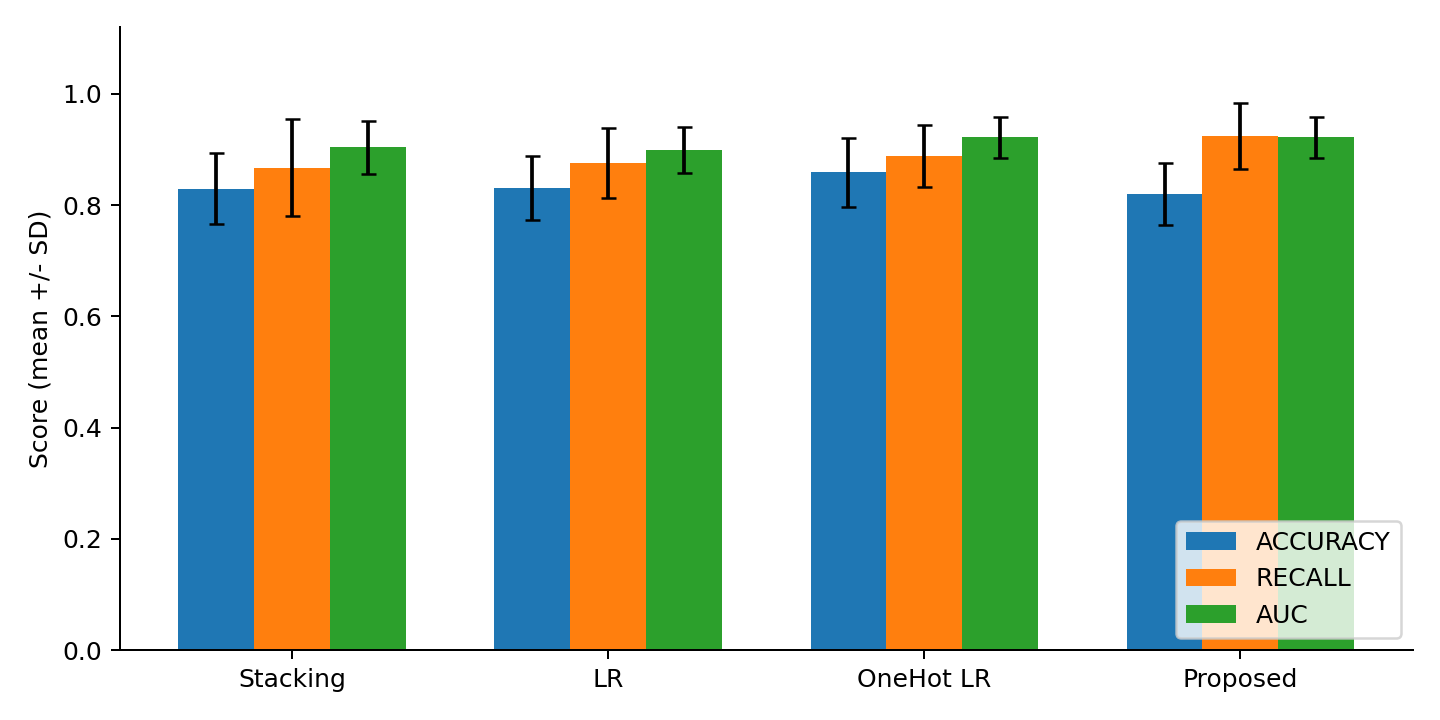

In [9]:
summary = pd.read_csv("results/part2_summary.csv").set_index("model")
display(summary[[m + suffix for m in METRICS for suffix in ["_mean", "_std"]]].round(4))
display(pd.read_csv("results/paired_comparison.csv").round(4))
display(Image(filename="results/figures/clean_comparison.png", width=800))

The full proposal improves average class-1 recall from **86.67% to 92.42%**
and AUC from **0.9039 to 0.9221**, compared with stacking. Accuracy falls from
**82.95% to 81.97%**, and precision is lower. We should not describe this as
better on every metric.

One-hot LR at 0.5 has mean accuracy **85.90%**, higher than the full proposal.
Thus feature representation helps, while threshold tuning changes the trade-off.
OneHot LR and Proposed share identical probabilities, so their AUC is identical.


,model,threshold,accuracy,precision,recall,f1,auc,tn,fp,fn,tp
7,LR,0.5,0.8033,0.8000,0.8485,0.8235,0.8712,21,7,5,28
8,DT,0.5,0.7213,0.7500,0.7273,0.7385,0.7208,20,8,9,24
9,RF,0.5,0.7541,0.7647,0.7879,0.7761,0.8588,20,8,7,26
10,XGB,0.5,0.7213,0.7353,0.7576,0.7463,0.8323,19,9,8,25
11,NB,0.5,0.7869,0.8333,0.7576,0.7937,0.8842,23,5,8,25
12,KNN,0.5,0.7869,0.7778,0.8485,0.8116,0.8377,20,8,5,28
13,Stacking,0.5,0.7705,0.7879,0.7879,0.7879,0.8777,21,7,7,26
14,OneHot LR,0.5,0.8361,0.8485,0.8485,0.8485,0.9048,23,5,5,28
15,Proposed,0.4,0.8197,0.8235,0.8485,0.8358,0.9048,22,6,5,28


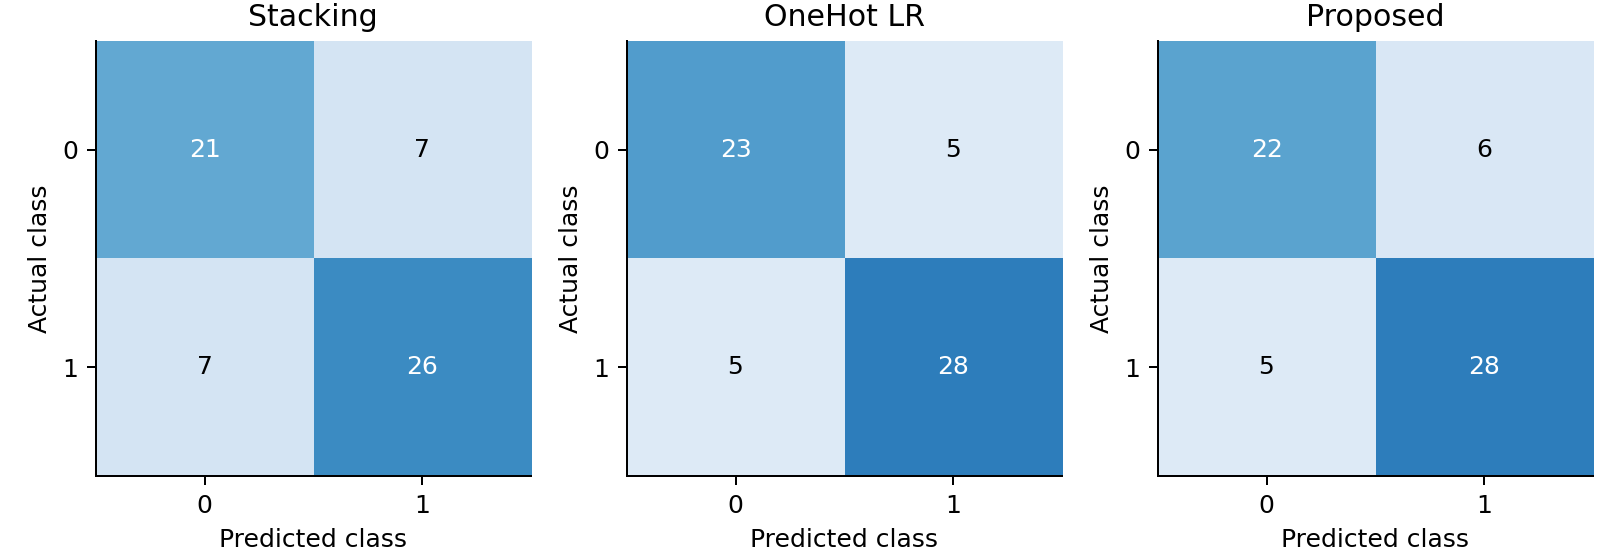

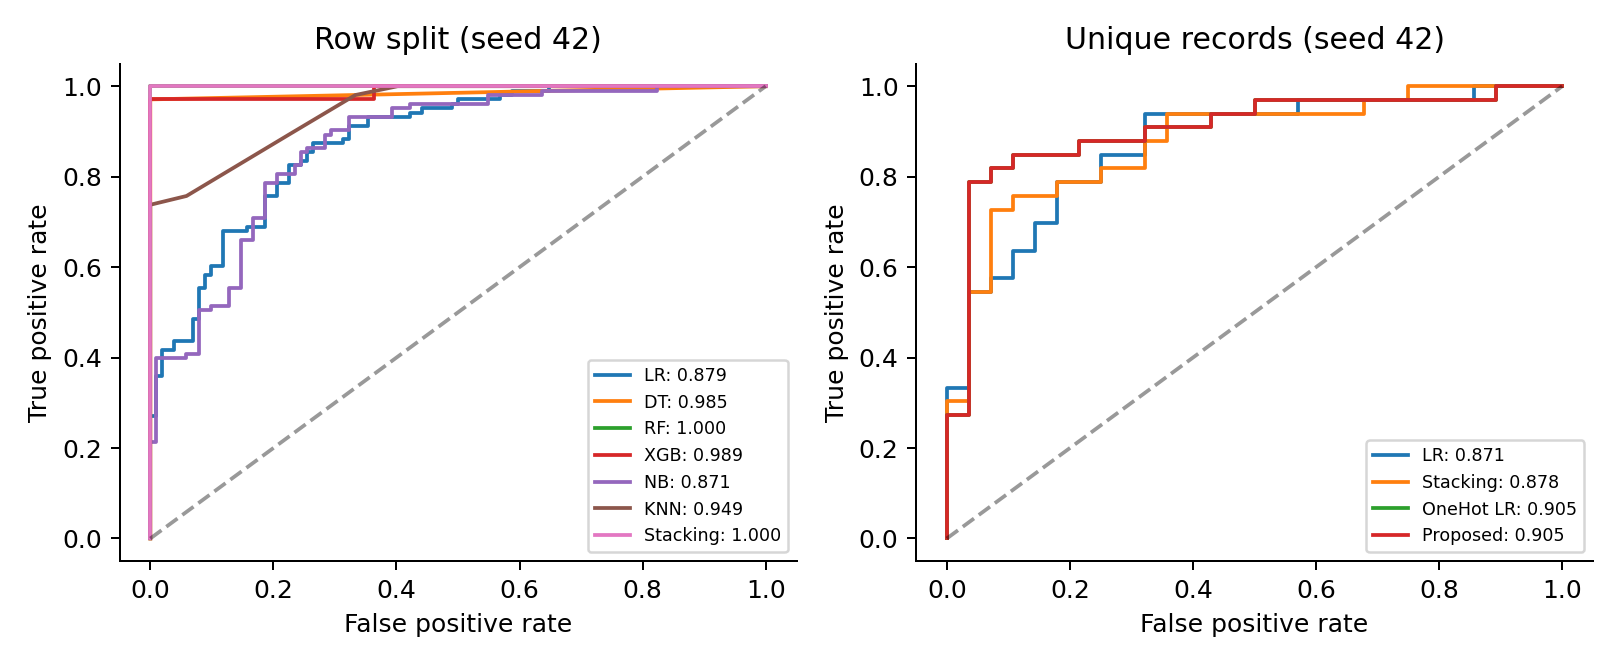

In [10]:
display(scores[(scores.protocol == "unique_rows") & (scores.seed == 42)]
        [["model", "threshold"] + METRICS + ["tn", "fp", "fn", "tp"]].round(4))
display(Image(filename="results/figures/confusion_matrices.png", width=900))
display(Image(filename="results/figures/roc_curves.png", width=900))

On seed 42, the proposal misses five positive records compared with seven
for stacking. But one-hot LR at threshold 0.5 also misses five, while producing
one fewer false positive than the proposal. This is a useful failure case:
training-based threshold tuning does not guarantee an improvement on every
unseen test set.

## 8. Verify the saved outputs

This check recalculates the five required metrics from saved predictions,
checks the split membership and confirms there is no exact-record overlap in
the clean experiments. It also checks the means and SDs used in the report.


In [11]:
from tools.verify_results import verify
verification_message = verify()

PASS: 97 metric rows and 6925 predictions verified; clean splits have no exact-record overlap.


## 9. What this study can and cannot conclude

- A small, understandable model can be competitive with a more complicated stack.
- Duplicate removal improves the credibility of evaluation, even if the score falls.
- The raw/clean score difference is not a controlled causal estimate: sample size,
  stratification and held-out records change too.
- The dataset is small, labels and unusual codes need stronger provenance checks,
  and distinct rows are not verified distinct patients.
- Repeated splits overlap and do not prove statistical significance.
- These are recorded labels, not verified future heart-attack outcomes.

The reports and presentation guide are in the `report/` folder.

## References

[1] M. Bhagat, A. Sharma and P. Agarwal, selected paper, 2025,
doi: [10.1007/s11042-024-19293-7](https://doi.org/10.1007/s11042-024-19293-7).

[2] J. Smith, [Heart Disease Dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset), Kaggle.

[3] S. Kapoor and A. Narayanan, "Leakage and the reproducibility crisis in
machine-learning-based science," *Patterns*, 2023,
doi: [10.1016/j.patter.2023.100804](https://doi.org/10.1016/j.patter.2023.100804).

[4] Scikit-learn developers, [StackingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html),
[common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html), and
[threshold tuning](https://scikit-learn.org/stable/modules/classification_threshold.html).

The report contains the full IEEE-style reference list.
